# OULAD -- Logistische Regression

Was sagt das Bestehen (Pass/Distinction vs. Fail) am besten voraus?

**Voraussetzung:** `oulad_zentrumsbericht.csv`, `oulad_klicks_frueh.csv` und `oulad_klicks_typ.csv` liegen im selben Ordner (Export-Abfragen dafuer: siehe `OULAD_2_analysis.sql`, Abschnitt "Regression / Export fuer Python").

Vier Modelle mit denselben demografischen Merkmalen, aber unterschiedlicher Aktivitaetsvariable:
- **Modell 1:** nur Demografie (Referenz)
- **Modell 2:** + Klicks ueber das gesamte Semester
- **Modell 3:** + Klicks nur aus den ersten 4 Wochen (zeitlich vor dem Ergebnis)
- **Modell 4b:** + Klicks auf `oucontent` und `forumng` einzeln (statt Gesamtklicks)

Ergebnisse und Einordnung: siehe `oulad_ergebnisse.md`, Abschnitt "Logistische Regression".

## 1. Bibliotheken und Daten laden

In [12]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [13]:
df = pd.read_csv("oulad_zentrumsbericht.csv")

# Nur Einschreibungen, die nicht abgebrochen wurden (Abbruch waere eine
# eigene, hier nicht gerechnete Fragestellung, siehe Vorbehalte)
d = df[df["final_result"] != "Withdrawn"].copy()
d["bestanden"] = d["final_result"].isin(["Pass", "Distinction"]).astype(int)

m = d.copy()
print(m.shape)

(14902, 15)


## 2. Merkmale aufbereiten

In [14]:
# IMD-Band als Zahl 1 (0-10%, staerkste Benachteiligung) bis 10 (90-100%)
imd_map = {"0-10%": 1, "10-20%": 2, "20-30%": 3, "30-40%": 4, "40-50%": 5,
           "50-60%": 6, "60-70%": 7, "70-80%": 8, "80-90%": 9, "90-100%": 10}
m["imd"] = m["imd_band"].map(imd_map)

# Vorabschluss auf 3 Stufen verdichtet (kleine Kategorien aus B3
# zusammengefasst: No Formal quals -> unter_A_Level, Post Graduate -> Studium)
bildung_map = {"No Formal quals": "unter_A_Level",
               "Lower Than A Level": "unter_A_Level",
               "A Level or Equivalent": "A_Level",
               "HE Qualification": "Studium",
               "Post Graduate Qualification": "Studium"}
m["bildung"] = m["highest_education"].map(bildung_map)

m["alter_35plus"] = (m["age_band"] != "0-35").astype(int)
m["disability_ja"] = (m["disability"] == "Y").astype(int)
m["weiblich"] = (m["gender"] == "F").astype(int)

# Zeilen ohne IMD-Wert koennen nicht ins Modell (Audit: BBB 63, DDD 280, FFF 367)
m = m.dropna(subset=["imd"])

print(f"Modellbasis: {len(m)} Einschreibungen (ohne Withdrawn, ohne fehlenden IMD-Wert)")

Modellbasis: 14336 Einschreibungen (ohne Withdrawn, ohne fehlenden IMD-Wert)


In [15]:
def odds_ratio_tabelle(modell):
    """OR, 95%-KI und p-Wert aus einem gefitteten Logit-Modell."""
    ci = modell.conf_int()
    return pd.DataFrame({
        "OR": np.exp(modell.params),
        "ci_unten": np.exp(ci[0]),
        "ci_oben": np.exp(ci[1]),
        "p": modell.pvalues,
    }).round(3)


# Formel-Basis (Demografie), fuer alle vier Modelle gleich.
# Referenzkategorien: bildung = unter_A_Level, code_module = BBB
formel_basis = ("bestanden ~ imd + C(bildung, Treatment('unter_A_Level'))"
                 " + alter_35plus + disability_ja + weiblich + C(code_module)")

## 3. Modell 1: nur Demografie

In [16]:
modell1 = smf.logit(formel_basis, data=m).fit(disp=0)
print(odds_ratio_tabelle(modell1))
print("Pseudo-R2:", round(modell1.prsquared, 3))

                                                      OR  ci_unten  ci_oben  \
Intercept                                          0.694     0.612    0.787   
C(bildung, Treatment('unter_A_Level'))[T.A_Level]  1.941     1.798    2.096   
C(bildung, Treatment('unter_A_Level'))[T.Studium]  2.207     1.966    2.477   
C(code_module)[T.DDD]                              0.830     0.750    0.919   
C(code_module)[T.FFF]                              1.095     0.985    1.218   
imd                                                1.099     1.085    1.114   
alter_35plus                                       1.348     1.242    1.464   
disability_ja                                      0.856     0.758    0.967   
weiblich                                           1.261     1.151    1.382   

                                                       p  
Intercept                                          0.000  
C(bildung, Treatment('unter_A_Level'))[T.A_Level]  0.000  
C(bildung, Treatment('unter_A_Le

## 4. Modell 2: + Klicks gesamtes Semester

In [17]:
# log1p wegen Schiefe (viele kleine Werte, wenige sehr grosse), je Modul
# standardisiert, weil die Klickmengen zwischen den Modulen stark streuen
# (FFF ca. 3x so viele Klicks wie BBB, siehe C1a)
m["klicks_z"] = (np.log1p(m["klicks_gesamt"])
                  .groupby(m["code_module"])
                  .transform(lambda x: (x - x.mean()) / x.std()))

modell2 = smf.logit(formel_basis + " + klicks_z", data=m).fit(disp=0)
print(odds_ratio_tabelle(modell2))
print("Pseudo-R2:", round(modell2.prsquared, 3))

                                                       OR  ci_unten  ci_oben  \
Intercept                                           1.474     1.250    1.738   
C(bildung, Treatment('unter_A_Level'))[T.A_Level]   2.047     1.853    2.261   
C(bildung, Treatment('unter_A_Level'))[T.Studium]   2.038     1.759    2.362   
C(code_module)[T.DDD]                               0.540     0.474    0.616   
C(code_module)[T.FFF]                               0.641     0.558    0.738   
imd                                                 1.081     1.063    1.099   
alter_35plus                                        0.797     0.715    0.888   
disability_ja                                       0.840     0.718    0.982   
weiblich                                            0.813     0.722    0.914   
klicks_z                                           12.719    11.554   14.002   

                                                       p  
Intercept                                          0.000  
C

## 5. Modell 3: + Klicks nur erste 4 Wochen

Zeitlich vor dem Ergebnis, daher weniger anfaellig fuer den Einwand "wer besteht, klickt laenger" als Modell 2.

In [18]:
fr = pd.read_csv("oulad_klicks_frueh.csv")
m = m.merge(fr, on=["code_module", "code_presentation", "id_student"], how="left")
m["klicks_frueh"] = m["klicks_frueh"].fillna(0)  # keine fruehen Klicks = 0

m["frueh_z"] = (np.log1p(m["klicks_frueh"])
                 .groupby(m["code_module"])
                 .transform(lambda x: (x - x.mean()) / x.std()))

modell3 = smf.logit(formel_basis + " + frueh_z", data=m).fit(disp=0)
print(odds_ratio_tabelle(modell3))
print("Pseudo-R2:", round(modell3.prsquared, 3))

                                                      OR  ci_unten  ci_oben  \
Intercept                                          0.896     0.783    1.026   
C(bildung, Treatment('unter_A_Level'))[T.A_Level]  2.018     1.859    2.192   
C(bildung, Treatment('unter_A_Level'))[T.Studium]  2.262     1.998    2.561   
C(code_module)[T.DDD]                              0.729     0.653    0.813   
C(code_module)[T.FFF]                              0.944     0.842    1.059   
imd                                                1.093     1.077    1.108   
alter_35plus                                       1.137     1.041    1.243   
disability_ja                                      0.860     0.754    0.981   
weiblich                                           1.107     1.003    1.221   
frueh_z                                            2.343     2.238    2.452   

                                                       p  
Intercept                                          0.113  
C(bildung, T

## 6. Modell 4b: + Materialtyp (oucontent, forumng)

Alle 6 Typen gleichzeitig sind nicht schaetzbar (zu hohe Korrelation, bis r=0.89 zwischen homepage und subpage -> "Singular Matrix"-Fehler). `quiz` zusaetzlich ausgeschlossen: in DDD nutzt niemand quiz (Streuung 0). `oucontent` und `forumng` haben die niedrigste Korrelation (r=0.44) und die hoechsten Klickanteile in C1a -> als einzige zwei gemeinsam ins Modell.

In [19]:
kt = pd.read_csv("oulad_klicks_typ.csv")
kt_breit = kt.pivot_table(index=["code_module", "code_presentation", "id_student"],
                           columns="activity_type", values="klicks",
                           fill_value=0).reset_index()
m = m.merge(kt_breit, on=["code_module", "code_presentation", "id_student"], how="left")

for typ in ["oucontent", "forumng"]:
    m[typ] = m[typ].fillna(0)
    m[typ + "_z"] = (np.log1p(m[typ])
                      .groupby(m["code_module"])
                      .transform(lambda x: (x - x.mean()) / x.std()))

modell4b = smf.logit(formel_basis + " + oucontent_z + forumng_z", data=m).fit(disp=0)
print(odds_ratio_tabelle(modell4b))
print("Pseudo-R2:", round(modell4b.prsquared, 3))

                                                      OR  ci_unten  ci_oben  \
Intercept                                          1.524     1.304    1.781   
C(bildung, Treatment('unter_A_Level'))[T.A_Level]  2.031     1.849    2.231   
C(bildung, Treatment('unter_A_Level'))[T.Studium]  2.157     1.874    2.483   
C(code_module)[T.DDD]                              0.508     0.448    0.576   
C(code_module)[T.FFF]                              0.674     0.590    0.770   
imd                                                1.083     1.066    1.100   
alter_35plus                                       0.926     0.837    1.025   
disability_ja                                      0.881     0.760    1.023   
weiblich                                           0.878     0.785    0.982   
oucontent_z                                        3.015     2.845    3.196   
forumng_z                                          2.803     2.654    2.960   

                                                   

## 7. Grafik: Koeffizienten-Plot (Forest Plot)

Odds Ratios mit 95%-Konfidenzintervall, pro Modell. Referenzlinie bei OR=1 (kein Effekt). Ausgefuellte Punkte = signifikant (p<0.05), offene Punkte = nicht signifikant. x-Achse logarithmisch, da OR multiplikativ zu lesen sind.

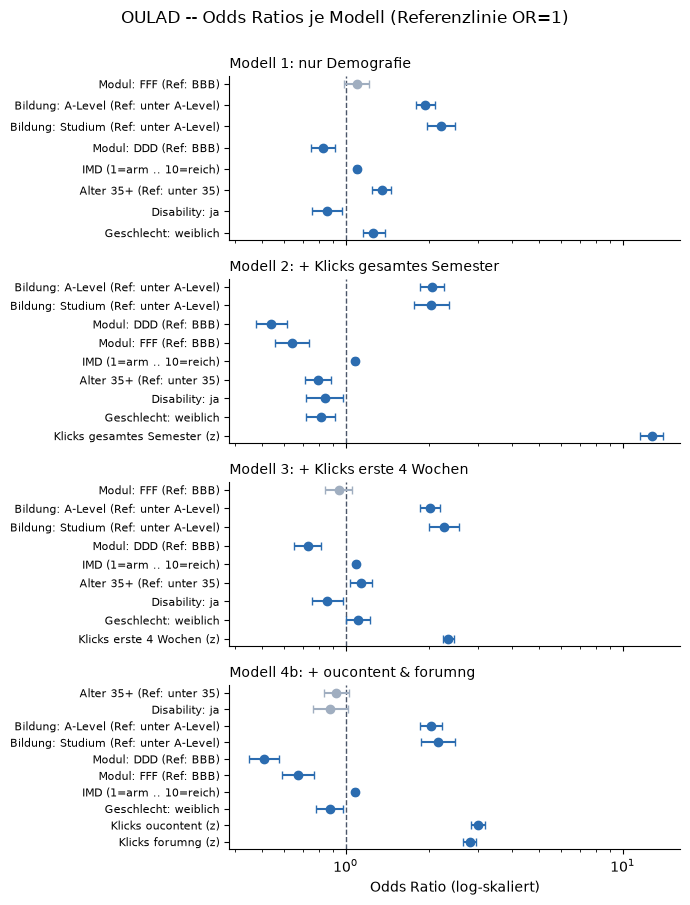

In [21]:
import matplotlib.pyplot as plt

# Beschriftungen fuer die Koeffizienten (lesbarer als die Patsy-Namen)
labels_basis = {
    "imd": "IMD (1=arm .. 10=reich)",
    "C(bildung, Treatment('unter_A_Level'))[T.A_Level]": "Bildung: A-Level (Ref: unter A-Level)",
    "C(bildung, Treatment('unter_A_Level'))[T.Studium]": "Bildung: Studium (Ref: unter A-Level)",
    "C(code_module)[T.DDD]": "Modul: DDD (Ref: BBB)",
    "C(code_module)[T.FFF]": "Modul: FFF (Ref: BBB)",
    "alter_35plus": "Alter 35+ (Ref: unter 35)",
    "disability_ja": "Disability: ja",
    "weiblich": "Geschlecht: weiblich",
    "klicks_z": "Klicks gesamtes Semester (z)",
    "frueh_z": "Klicks erste 4 Wochen (z)",
    "oucontent_z": "Klicks oucontent (z)",
    "forumng_z": "Klicks forumng (z)",
}

modelle = [
    ("Modell 1: nur Demografie", modell1),
    ("Modell 2: + Klicks gesamtes Semester", modell2),
    ("Modell 3: + Klicks erste 4 Wochen", modell3),
    ("Modell 4b: + oucontent & forumng", modell4b),
]

# gemeinsame x-Achsen-Grenzen ueber alle Modelle, damit man Modelle vergleichen kann
alle_or = pd.concat([odds_ratio_tabelle(mod).drop("Intercept") for _, mod in modelle])
x_min, x_max = alle_or["ci_unten"].min() * 0.85, alle_or["ci_oben"].max() * 1.15

farbe_sig = "#2b6cb0"        # signifikant (p<0.05)
farbe_nicht_sig = "#a0aec0"  # nicht signifikant

fig, achsen = plt.subplots(len(modelle), 1, figsize=(7, 9), sharex=True)

for ax, (titel, mod) in zip(achsen, modelle):
    tab = odds_ratio_tabelle(mod).drop("Intercept")
    tab = tab.rename(index=labels_basis)
    tab = tab.iloc[::-1]  # von oben nach unten in Formel-Reihenfolge

    # getrennt zeichnen (nicht als eine Liste von Farben in einem Aufruf,
    # das fuehrt bei manchen matplotlib-Versionen zu einem RGBA-Fehler)
    for ist_sig, farbe in [(True, farbe_sig), (False, farbe_nicht_sig)]:
        teil = tab[(tab["p"] < 0.05) == ist_sig]
        if teil.empty:
            continue
        fehler = [teil["OR"] - teil["ci_unten"], teil["ci_oben"] - teil["OR"]]
        ax.errorbar(teil["OR"], teil.index, xerr=fehler, fmt="o",
                     color=farbe, ecolor=farbe, elinewidth=1.5,
                     capsize=3, markersize=6, zorder=3)

    ax.axvline(1, color="#4a5568", linestyle="--", linewidth=1)
    ax.set_xscale("log")
    ax.set_xlim(x_min, x_max)
    ax.set_title(titel, fontsize=10, loc="left")
    ax.tick_params(axis="y", labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)

achsen[-1].set_xlabel("Odds Ratio (log-skaliert)")
fig.suptitle("OULAD -- Odds Ratios je Modell (Referenzlinie OR=1)", fontsize=12, y=1.0)
fig.tight_layout()
plt.savefig("oulad_regression_koeffizienten.png", dpi=150, bbox_inches="tight")
plt.show()

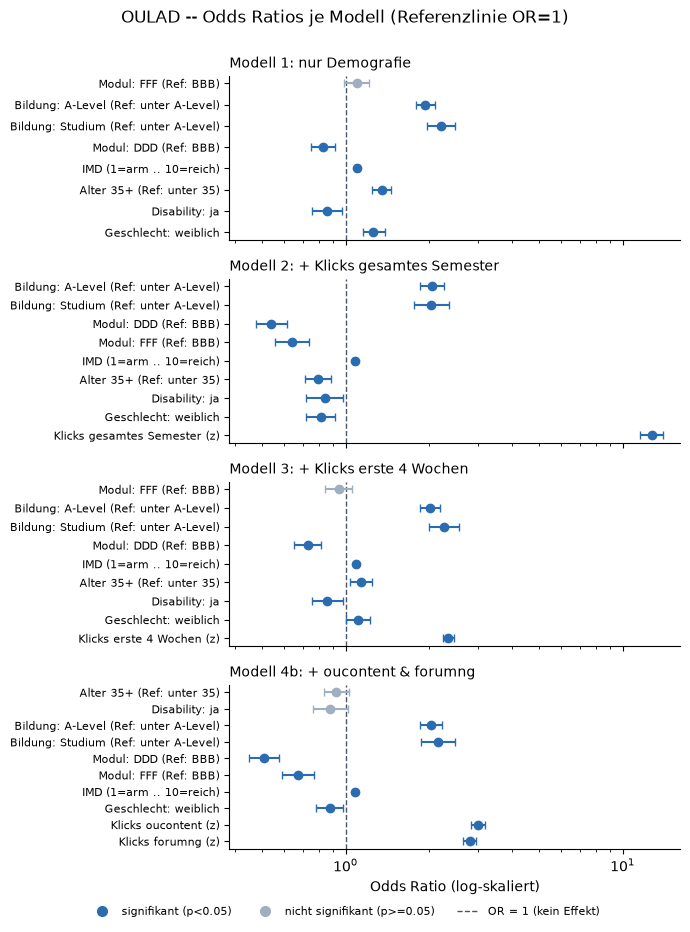

In [22]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Beschriftungen fuer die Koeffizienten (lesbarer als die Patsy-Namen)
labels_basis = {
    "imd": "IMD (1=arm .. 10=reich)",
    "C(bildung, Treatment('unter_A_Level'))[T.A_Level]": "Bildung: A-Level (Ref: unter A-Level)",
    "C(bildung, Treatment('unter_A_Level'))[T.Studium]": "Bildung: Studium (Ref: unter A-Level)",
    "C(code_module)[T.DDD]": "Modul: DDD (Ref: BBB)",
    "C(code_module)[T.FFF]": "Modul: FFF (Ref: BBB)",
    "alter_35plus": "Alter 35+ (Ref: unter 35)",
    "disability_ja": "Disability: ja",
    "weiblich": "Geschlecht: weiblich",
    "klicks_z": "Klicks gesamtes Semester (z)",
    "frueh_z": "Klicks erste 4 Wochen (z)",
    "oucontent_z": "Klicks oucontent (z)",
    "forumng_z": "Klicks forumng (z)",
}

modelle = [
    ("Modell 1: nur Demografie", modell1),
    ("Modell 2: + Klicks gesamtes Semester", modell2),
    ("Modell 3: + Klicks erste 4 Wochen", modell3),
    ("Modell 4b: + oucontent & forumng", modell4b),
]

# gemeinsame x-Achsen-Grenzen ueber alle Modelle, damit man Modelle vergleichen kann
alle_or = pd.concat([odds_ratio_tabelle(mod).drop("Intercept") for _, mod in modelle])
x_min, x_max = alle_or["ci_unten"].min() * 0.85, alle_or["ci_oben"].max() * 1.15

farbe_sig = "#2b6cb0"        # signifikant (p<0.05)
farbe_nicht_sig = "#a0aec0"  # nicht signifikant

fig, achsen = plt.subplots(len(modelle), 1, figsize=(7, 9), sharex=True)

for ax, (titel, mod) in zip(achsen, modelle):
    tab = odds_ratio_tabelle(mod).drop("Intercept")
    tab = tab.rename(index=labels_basis)
    tab = tab.iloc[::-1]  # von oben nach unten in Formel-Reihenfolge

    # getrennt zeichnen (nicht als eine Liste von Farben in einem Aufruf,
    # das fuehrt bei manchen matplotlib-Versionen zu einem RGBA-Fehler)
    for ist_sig, farbe in [(True, farbe_sig), (False, farbe_nicht_sig)]:
        teil = tab[(tab["p"] < 0.05) == ist_sig]
        if teil.empty:
            continue
        fehler = [teil["OR"] - teil["ci_unten"], teil["ci_oben"] - teil["OR"]]
        ax.errorbar(teil["OR"], teil.index, xerr=fehler, fmt="o",
                     color=farbe, ecolor=farbe, elinewidth=1.5,
                     capsize=3, markersize=6, zorder=3)

    ax.axvline(1, color="#4a5568", linestyle="--", linewidth=1)
    ax.set_xscale("log")
    ax.set_xlim(x_min, x_max)
    ax.set_title(titel, fontsize=10, loc="left")
    ax.tick_params(axis="y", labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)

achsen[-1].set_xlabel("Odds Ratio (log-skaliert)")
fig.suptitle("OULAD -- Odds Ratios je Modell (Referenzlinie OR=1)", fontsize=12, y=1.0)

# Legende: Punkt = OR-Schaetzung, Balken = 95%-KI, Farbe = Signifikanz
legenden_elemente = [
    Line2D([0], [0], marker="o", color=farbe_sig, linestyle="none",
           markersize=7, label="signifikant (p<0.05)"),
    Line2D([0], [0], marker="o", color=farbe_nicht_sig, linestyle="none",
           markersize=7, label="nicht signifikant (p>=0.05)"),
    Line2D([0], [0], color="#4a5568", linestyle="--", linewidth=1,
           label="OR = 1 (kein Effekt)"),
]
fig.legend(handles=legenden_elemente, loc="lower center", ncol=3,
           bbox_to_anchor=(0.5, -0.02), frameon=False, fontsize=8)

fig.tight_layout()
plt.savefig("oulad_regression_koeffizienten.png", dpi=150, bbox_inches="tight")
plt.show()